In [1]:
# Relevant packages for Stanford data visualization
import open3d as o3d
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [16]:
def apply_colormap(data, transform='linear'):
    if transform == 'log':
        norm = mcolors.LogNorm()(data)
    elif transform == 'power':
        norm = data**3  # Using a power of 0.3 as an example
    else:
        norm = data
    colors = plt.cm.RdBu(norm)
    return colors

import pandas as pd
import plotly.express as px


def plot_vs(points, viewpoint, visibility=None, out_file=None, point_size=3, plot_viewpoint=False, eye_vec=None):
    if visibility:
        df_3d = pd.DataFrame({'x': points[:, 0], 'y': points[:, 1], 'z': points[:, 2], 'visibility': visibility})
        reversed_jet = px.colors.sequential.Jet[::-1]
        fig = px.scatter_3d(df_3d, x='x', y='y', z='z', color='visibility', title='Visibility Score for Stanford Bunny',
                            color_continuous_scale=reversed_jet, range_color=[0, 1])  # , range_color=[0, 1]
    else:
        df_3d = pd.DataFrame({'x': points[:, 0], 'y': points[:, 1], 'z': points[:, 2]})
        fig = px.scatter_3d(df_3d, x='x', y='y', z='z', title='Visibility Score for Stanford Bunny')

    fig.update_traces(marker=dict(size=point_size))  # Adjust the size value as needed

    # Create a Scatter3d object for the viewpoint
    if plot_viewpoint:
        scatter_viewpoint = go.Scatter3d(
            x=[viewpoint[0]], 
            y=[viewpoint[1]], 
            z=[viewpoint[2]], 
            mode='markers',
            marker=dict(
                size=10,
                color='pink',
                opacity=0.5
            )
        )
        fig.add_trace(scatter_viewpoint)

    fig.update_layout(
        autosize=False,
        width=500,
        height=500,
        margin=dict(
            l=0,  # left margin
            r=0,  # right margin
            b=0,  # bottom margin
            t=0,  # top margin
            pad=0  # padding
        ),
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            camera=dict(
                up=dict(x=0, y=1, z=0),
                center=dict(x=0, y=0, z=0),
                eye=dict(x=viewpoint[0], y=viewpoint[1], z=viewpoint[2])  # Adjust the eye position here
            )
        ),
        showlegend=False,
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)',
    )

    if eye_vec is not None:
    # # Update the figure layout
        fig.update_layout(scene_camera=dict(eye=dict(x=eye_vec[0], y=eye_vec[1], z=eye_vec[2])))

    fig.show()
    if out_file is not None:
        pio.write_image(fig, out_file)
    #return fig


def plot_points(points, viewpoint, plot_viewpoint=True, 
                points_special_inds=None, extra_viewpoint=None, out_file="output.eps",
                save=True, visibility_scores=None):

    # If visibility scores are provided, use them to determine colors
    if visibility_scores is not None:
        # colorscale = [[0, 'red'], [1, 'blue']]
        # colors = np.interp(visibility_scores, (visibility_scores.min(), visibility_scores.max()), [0, 1])
        #colors = apply_colormap(visibility_scores)
        colors = visibility_scores
        # colors_sorted = plt.cm.RdBu(np.linspace(0, 1, len(visibility_scores)))
        # # Sorting the torch tensor and getting the indices
        # sorted_indices = torch.argsort(visibility_scores)

        # # Using the sorted colors to color the original data points
        # colors = colors_sorted[sorted_indices.numpy()]
    else:
        colors = 'blue'

    # Prepare point clouds
    if points_special_inds is not None:
        scatter_points_special = go.Scatter3d(
            x=points[points_special_inds, 0], 
            y=points[points_special_inds, 1], 
            z=points[points_special_inds, 2], 
            mode='markers',
            marker=dict(
                size=0.7,
                opacity=1,
                color='green'  # Keep special points as green for now
            )
        )

        scatter_points_normal = go.Scatter3d(
            x=np.delete(points[:, 0], points_special_inds), 
            y=np.delete(points[:, 1], points_special_inds), 
            z=np.delete(points[:, 2], points_special_inds), 
            mode='markers',
            marker=dict(
                size=0.7,
                opacity=1,
                color=colors
            )
        )
    else:
        scatter_points_normal = go.Scatter3d(
            x=points[:, 0], 
            y=points[:, 1], 
            z=points[:, 2], 
            mode='markers',
            marker=dict(
                size=0.7,
                opacity=1,
                color=colors
            )
        )
    # Store point clouds
    data = [scatter_points_normal]

    if points_special_inds is not None:
        data.append(scatter_points_special)

    # Create a Scatter3d object for the viewpoint
    if plot_viewpoint:
        scatter_viewpoint = go.Scatter3d(
            x=[viewpoint[0]], 
            y=[viewpoint[1]], 
            z=[viewpoint[2]], 
            mode='markers',
            marker=dict(
                size=10,
                color='blue',
                opacity=1
            )
        )
        data.append(scatter_viewpoint)

    if extra_viewpoint is not None:
        scatter_extra_viewpoint = go.Scatter3d(
            x=[extra_viewpoint[0]], 
            y=[extra_viewpoint[1]], 
            z=[extra_viewpoint[2]], 
            mode='markers',
            marker=dict(
                size=10,
                color='yellow',
                opacity=1
            )
        )
        data.append(scatter_extra_viewpoint)
        
    fig = go.Figure(data=data)


    # Update layout to remove background and axes
    fig.update_layout(
        autosize=False,
        width=500,
        height=500,
        margin=dict(
            l=0,  # left margin
            r=0,  # right margin
            b=0,  # bottom margin
            t=0,  # top margin
            pad=0  # padding
        ),
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            camera=dict(
                up=dict(x=0, y=1, z=0),
                center=dict(x=0, y=0, z=0),
                eye=dict(x=viewpoint[0], y=viewpoint[1], z=viewpoint[2])  # Adjust the eye position here
            )
        ),
        showlegend=False,
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)',
    )
    import random
    eye_x = random.uniform(-1, 1)
    eye_y = random.uniform(-1, 1)
    eye_z = random.uniform(-1, 1)
    
    # # Update the figure layout
    fig.update_layout(scene_camera=dict(eye=dict(x=eye_x, y=eye_y, z=eye_z)))
    
    # # Show the plot
    fig.show()
    if save:
        pio.write_image(fig, out_file)

In [14]:
import open3d as o3d

pcd = o3d.io.read_point_cloud("data/stanford/bunny/reconstruction/bun_zipper.ply")
#pcd = o3d.io.read_point_cloud("data/stanford/Armadillo_scans/ArmadilloBack_0.ply")
import time
import numpy as np
import importlib
import utils.visibility
importlib.reload(utils.visibility)
from utils.visibility import visible_points


points = np.asarray(pcd.points)
radius = 3.25
kernel = "spherical_flipping"
#viewpoint = np.array([2, 0, -1.55])
#viewpoint = np.array([-0.0172, -0.0936, -1.55])

viewpoint = np.array([0, 0.15, -1])
#viewpoint = np.array([2, 0, -1.55])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
points = torch.tensor(points, device=device)
viewpoint = torch.tensor(viewpoint, device=device)

# start = time.time()
# visible_inds = visible_points(points, viewpoint, hpr_radius=radius, compute_weights=False)
# end = time.time()
# print(f"Time taken without vs: {np.around(end-start, 3)}")

start = time.time()
visible_inds, visibility_scores = visible_points(points, viewpoint, hpr_radius=radius, compute_weights=True,
                                                 inversion_kernel=kernel, gamma=-0.001)
# visible_inds, visibility_scores = visible_points(points, viewpoint, hpr_radius=radius, compute_weights=True)
end = time.time()
# visibility_scores = visibility_scores - visibility_scores.min()
# visibility_scores = visibility_scores/visibility_scores.max()
visibility_scores = visibility_scores.cpu().numpy()
viewpoint_np = viewpoint.cpu().numpy()
print(f"Time taken with vs: {np.around(end-start, 3)}")

points_viewpoint = points[visible_inds].cpu().numpy()

folder = 'images/point_clouds/stanford/'
plot_vs(points_viewpoint, visibility_scores, viewpoint_np, out_file=folder + 'bunny_visibility_score_debug.eps',
        point_size=1)
#plot_points(points_viewpoint, viewpoint, plot_viewpoint=True, visibility_scores=visibility_scores)
#plot_points(noisy_point_viewpoint, viewpoint, plot_viewpoint=False, out_file=folder + 'bunny_visibility_score.eps', visibility_scores=noisy_visibility_scores)

Time taken with vs: 0.391


In [ ]:

import utils.visibility
importlib.reload(utils.visibility)
from utils.visibility import visible_points

start = time.time()
visible_inds, visibility_scores = visible_points(points, viewpoint, hpr_radius=radius, compute_weights=True)
end = time.time()

In [ ]:
%%timeit
visible_inds, visibility_scores = visible_points(points, viewpoint, hpr_radius=radius, compute_weights=True, inversion_kernel="exponential")

In [ ]:
A = torch.rand((256, 50))
B = torch.rand((256, 50))
print(torch.equal(torch.pow(A,2), A**2))

In [ ]:
%%timeit
torch.mul(A,B)

In [33]:
print("hej dp")
pcd = o3d.io.read_point_cloud("data/stanford/bunny/reconstruction/bun_zipper.ply")
import utils.visibility
import importlib
importlib.reload(utils.visibility)
from utils.visibility import visible_points, covisible_inds


points = np.asarray(pcd.points)
n_points = points.shape[0]
radius = 4
kernel = "exponential"
#kernel = "spherical_flipping"
gamma = -0.0001

viewpoint0 = np.array([0, 0.15, -1.55])
# viewpoint0 = np.array([-0.0172, -0.0936, -0.734])
viewpoint1 = np.array([2, 0.15, -1.55])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
points = torch.tensor(points, device=device)
dtype = points.dtype
viewpoint0 = torch.tensor(viewpoint0, device=device, dtype=dtype)
viewpoint1 = torch.tensor(viewpoint1, device=device, dtype=dtype)

rot_hom = torch.vstack((torch.eye(3, device=device, dtype=dtype), torch.zeros(3, device=device, dtype=dtype)))
one = torch.ones(1, device=device, dtype=dtype)
T0 = torch.cat((rot_hom, torch.cat((viewpoint0, one))[:, None]), dim=1)
T1 = torch.cat((rot_hom, torch.cat((viewpoint1, one))[:, None]), dim=1)

# Sample the pointcloud from two viewpoints
visible_inds0 = visible_points(points, viewpoint0, hpr_radius=radius, compute_weights=False,
                               inversion_kernel=kernel, gamma=gamma)
points_viewpoint0 = points[visible_inds0]
n_points0 = points_viewpoint0.shape[0]

visible_inds1 = visible_points(points, viewpoint1, hpr_radius=radius, compute_weights=False,
                               inversion_kernel=kernel, gamma=gamma)
points_viewpoint1 = points[visible_inds1]
n_points1 = points_viewpoint1.shape[0]

# Move both sampled point cloud to CS0
points_permuted = torch.swapaxes(points_viewpoint0, axis0=1, axis1=0)
points_homog = torch.vstack((points_permuted, torch.ones(n_points0, device=device, dtype=dtype)))
pc0 = torch.swapaxes(torch.matmul(torch.inverse(T0), points_homog)[:3], axis0=1, axis1=0)

points_permuted = torch.swapaxes(points_viewpoint1, axis0=1, axis1=0)
points_homog = torch.vstack((points_permuted, torch.ones(n_points1, device=device, dtype=dtype)))
pc1_CS0 = torch.swapaxes(torch.matmul(torch.inverse(T0), points_homog)[:3], axis0=1, axis1=0)

pc_union = torch.vstack((pc0, pc1_CS0))

# The co-visible inds in joint point cloud
visible_inds, visible_inds_pc0, visible_inds_pc1 = covisible_inds(
    pc0, pc_union, T0, T1, hpr_radius=radius, compute_weights=False, inversion_kernel=kernel, gamma=gamma)


pc_union_cov = pc_union[visible_inds]
n_points1_cov = pc_union_cov.shape[0]

points_permuted = torch.swapaxes(pc_union_cov, axis0=1, axis1=0)
points_homog = torch.vstack((points_permuted, torch.ones(n_points1_cov, device=device)))
pc_union_cov_WCS = torch.swapaxes(torch.matmul(T0, points_homog)[:3], axis0=1, axis1=0)

# Approx GT co-visible points
pc_union_ground_truth_inds = np.intersect1d(visible_inds0, visible_inds1)
pc_union_ground_truth = points[pc_union_ground_truth_inds]

plot_vs(points_viewpoint0.cpu().numpy(), viewpoint=viewpoint0.cpu().numpy(), out_file=folder + 'bunny_visibility_score_view0_upd2.eps',
        point_size=1)
plot_vs(points_viewpoint1.cpu().numpy(), viewpoint=viewpoint1.cpu().numpy(), out_file=folder + 'bunny_visibility_score_view1_upd2.eps',
        point_size=1)
plot_vs(pc_union_ground_truth.cpu().numpy(), viewpoint=viewpoint0.cpu().numpy(), out_file=folder + 'bunny_visibility_score_view0_gt_approx2.eps',
        point_size=1)
plot_vs(pc_union_cov_WCS.cpu().numpy(), viewpoint=viewpoint0.cpu().numpy(), out_file=folder + 'bunny_visibility_score_view0_est_cov2.eps',
        point_size=1)
#plot_points(points_viewpoint0.cpu().numpy(), viewpoint0.cpu().numpy(), plot_viewpoint=False, out_file=folder + 'bunny_view0.eps')
#plot_points(points_viewpoint1.cpu().numpy(), viewpoint1.cpu().numpy(), plot_viewpoint=False, out_file=folder + 'bunny_view1.eps')
#plot_points(pc_union_ground_truth.cpu().numpy(), viewpoint0.cpu().numpy(), plot_viewpoint=False, out_file = folder + 'approx_gt_covisible.eps')
#plot_points(pc_union_cov_WCS.cpu().numpy(), viewpoint0.cpu().numpy(), plot_viewpoint=False, out_file = folder + 'est_covisible.eps')

hej dp


In [ ]:
# Recreate minimal case which causes problems:
print("hej dp")
pcd = o3d.io.read_point_cloud("data/stanford/bunny/reconstruction/bun_zipper.ply")
import utils.visibility
import importlib
importlib.reload(utils.visibility)
from utils.visibility import visible_points, covisible_inds


points = np.asarray(pcd.points)
n_points = points.shape[0]
radius = 3.25
gamma = -0.0005

viewpoint0 = np.array([0, 0, -1.55])
viewpoint1 = np.array([2, 0, -1.55])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
points = torch.tensor(points, device=device)
dtype = points.dtype
n_points = points.shape[0]
viewpoint0 = torch.tensor(viewpoint0, device=device, dtype=dtype)
viewpoint1 = torch.tensor(viewpoint1, device=device, dtype=dtype)


# Get surface samples from viewpoint0
visible_inds0, visibility_scores0 = visible_points(points, viewpoint0, hpr_radius=radius, compute_weights=True,
                                                   inversion_kernel="exponential", gamma=gamma)
points_viewpoint0 = points[visible_inds0]
n_points0 = points_viewpoint0.shape[0]


# Estimate T0 and T1, (#TODO Perhaps T0 is wrong)
rot_hom = torch.vstack((torch.eye(3, device=device, dtype=dtype), torch.zeros(3, device=device, dtype=dtype)))
#
a1 = 0
a2 = 2
# rot_hom[a1, a1] = torch.cos(torch.tensor(torch.pi))
# rot_hom[a2, a2] = torch.cos(torch.tensor(torch.pi))
# rot_hom[a1, a2] = -torch.sin(torch.tensor(torch.pi))
# rot_hom[a2, a1] = torch.sin(torch.tensor(torch.pi))

one = torch.ones(1, device=device, dtype=dtype)
T0 = torch.cat((rot_hom, torch.cat((viewpoint0, one))[:, None]), dim=1)

points_permuted = torch.swapaxes(points, axis0=1, axis1=0)
points_homog = torch.vstack((points_permuted, torch.ones(n_points, device=device, dtype=dtype)))
points_CS0 = torch.swapaxes(torch.matmul(torch.inverse(T0), points_homog)[:3], axis0=1, axis1=0)

# Sample in CS0
zero_vec = torch.zeros((3), device=device, dtype=dtype)
visible_inds0_CS0, visibility_scores0_CS0 = visible_points(points_CS0, zero_vec, hpr_radius=radius, compute_weights=True,
                                                           inversion_kernel="exponential", gamma=gamma)

points_viewpoint0_CS0 = points_CS0[visible_inds0_CS0]

folder = 'images/point_clouds/stanford/'
# Visualize in WCS
plot_vs(points_viewpoint0.cpu().numpy(), visibility_scores0.cpu().numpy(), viewpoint0.cpu().numpy(),
        out_file=folder + 'bunny_visibility_score_debug.eps', point_size=3)
# Visualize in CS0
plot_vs(points_viewpoint0_CS0.cpu().numpy(), visibility_scores0_CS0.cpu().numpy(), zero_vec.cpu().numpy(),
        out_file=folder + 'bunny_visibility_score_debug.eps', point_size=3)

In [ ]:
import nuscenes as ns

# Init Nusc object
data_folder = 'data/nuscenes/'
version = 'v1.0-mini'
nusc = ns.nuscenes.NuScenes(version=version, dataroot=data_folder, verbose=False)

In [ ]:
# Some visualization on visibility on the separate Nuscens point clouds

from utils.data_handling import split_data
import utils.nuscenes_handling
importlib.reload(utils.nuscenes_handling)
from utils.nuscenes_handling import read_nuscenes_data
import utils.visibility
import importlib
importlib.reload(utils.visibility)
from utils.visibility import visible_points, covisible_inds
import torch
# Set params
N = 1
T_close_thresh = 1.5
gamma = -0.00000001
radius = 10
kernel = "spherical_flipping"
#skernel = "exponential"

class Settings:
    def __init__(self, n_classes, r_bin, t_bin, class_distribution):
        self.n_classes = n_classes
        self.r_bin = r_bin
        self.t_bin = t_bin
        self.class_distribution = class_distribution


class CovSettings:
    def __init__(self, inversion_kernel, gamma, hpr_radius):
        self.inversion_kernel = inversion_kernel
        self.gamma = gamma
        self.hpr_radius = hpr_radius


perturb_settings = Settings(n_classes=2, r_bin=0.03, t_bin=0.3, class_distribution='uniform')
covisiblity_settings = CovSettings(inversion_kernel=kernel, gamma=gamma, hpr_radius=radius)


#
PC_scenes = read_nuscenes_data(nusc, perturb_settings=perturb_settings, downsample_factor=1,
                               n_scenes=N, n_samples=N, T_close_thresh=T_close_thresh, use_c=False,
                               cov_params=covisiblity_settings)
PC_scenes_training, PC_scenes_test = split_data(PC_scenes, scenes_training=N)

for i in range(len(PC_scenes_training)):
    PC_pair = PC_scenes_training[i][0]
    pc_in = PC_pair.PC0.pc
    device = pc_in.device
    dtype = pc_in.dtype

    zero_vec = torch.zeros((3), device=device, dtype=dtype)
    T0 = PC_pair.pose0
    T1 = PC_pair.pose1
    viewpoint1_CS0 = torch.matmul(torch.linalg.inv(T0), T1)[:3, 3]
    viewpoint = zero_vec.cpu().numpy()


    #
    print(f"\nScene: {i}")
    #for gamma in [-0.001, -0.00033, -0.0001, -0.000033, -0.00001]:
    for radius in [2, 2.75, 3.5, 4.25]:
        # visible_inds, visibility_scores = visible_points(pc_in, zero_vec, hpr_radius=radius, compute_weights=True,
        #                                                  inversion_kernel = "exponential", gamma=gamma)
        # visible_inds_other, visibility_scores_other = visible_points(
        #     pc_in, viewpoint1_CS0, hpr_radius=radius, compute_weights=True, gamma=gamma)
        visible_inds_union, visible_inds_pc0, visible_inds_pc1, visibility_scores_union = covisible_inds(
            PC_pair.PC0.pc, PC_pair.PCUnion.pc, T0, T1, compute_weights=True, inversion_kernel=kernel,
            hpr_radius=radius, gamma=gamma)
        print(f"Visible inds {visible_inds_union.shape[0]} for {radius}")
        print(f"class category {PC_pair.class_category}")
        # # print(f"Percentage visible points own viewpoint vs other " +
        # #       f"{np.around(100*len(visible_inds)/pc_in.shape[0], 3)} % vs "+
        # #       f"{np.around(100*len(visible_inds_other)/pc_in.shape[0], 3)} %")
        # print("Covisible point percentage in union point cloud ",
        #       f"{np.around(100*visible_inds.shape[0]/PC_pair.PCUnion.N_points,2)} %")
#plot_points(pc_in, zero_vec, points_special_inds=visible_inds, extra_viewpoint=viewpoint1_CS0)
        # pc_union = PC_pair.PCUnion.pc.cpu().numpy()
        # pc_out = pc_in[visible_inds].cpu().numpy()
        # visibility_scores = visibility_scores.cpu().numpy()

        pc_union_plot = PC_pair.PCUnion.pc[visible_inds_union].cpu().numpy()
        visibility_scores_union = visibility_scores_union.cpu().numpy()
        # pc_union = pc_union[~visible_inds]
        #plot_vs(pc_out, visibility_scores, viewpoint, point_size=1)
        plot_vs(pc_union_plot, visibility_scores_union, viewpoint, point_size=1)
# plot_points(np.delete(pc_union, visible_inds, axis=0), viewpoint=zero_vec, plot_viewpoint=False)
# plot_points(pc_union[visible_inds], viewpoint=zero_vec, plot_viewpoint=False)


In [ ]:
# Some visualization on visibility on the joint Nuscens point clouds

from utils.data_handling import split_data
from utils.nuscenes_handling import read_nuscenes_data
from utils.visibility import covisible_inds, visible_points
import torch
import numpy as np
# Set params
N = 10
samples_per_scene = 1
N_samples = N*samples_per_scene
T_close_thresh = 1.5
hpr_rads = np.arange(2, 5, 0.25)
exp_rads = [-0.00001, -0.0001, -0.001]
#
gamma = -0.00000001
radius = 10
#kernel = "spherical_flipping"
kernel = "exponential"

class Settings:
    def __init__(self, n_classes, r_bin, t_bin, class_distribution):
        self.n_classes = n_classes
        self.r_bin = r_bin
        self.t_bin = t_bin
        self.class_distribution = class_distribution


class CovSettings:
    def __init__(self, inversion_kernel, gamma, hpr_radius):
        self.inversion_kernel = inversion_kernel
        self.gamma = gamma
        self.hpr_radius = hpr_radius

perturb_settings = Settings(n_classes=2, r_bin=1, t_bin=10, class_distribution='uniform')
covisiblity_settings = CovSettings(inversion_kernel=kernel, gamma=gamma, hpr_radius=radius)
#
PC_scenes_training = read_nuscenes_data(nusc, perturb_settings=perturb_settings, downsample_factor=1,
                                        n_scenes=N, n_samples=N_samples, T_close_thresh=T_close_thresh, use_c=False,
                                        cov_params=covisiblity_settings)
# Initialize dictionaries to store the sum of percentages for each radius
# sum_visible_perc_own = {rad: 0 for rad in hpr_rads}
# sum_visible_perc_other = {rad: 0 for rad in hpr_rads}
sum_visible_perc_own = {rad: 0 for rad in exp_rads}
sum_visible_perc_other = {rad: 0 for rad in exp_rads}

def T_random(angular_offset=0.01, translational_offset=0.1):
    cos_off = torch.cos(torch.tensor(angular_offset))
    sin_off = torch.sin(torch.tensor(angular_offset))
    R_peturb = torch.tensor([[cos_off,  -sin_off,   0],
                             [sin_off,  cos_off,    0],
                             [0,        0,          1]])

    # Define random translation offset of 0.1m in (x,y)-plane
    random_xy_offset = torch.rand((2, 1))
    scaled_random_xy_offset = translational_offset*random_xy_offset/torch.norm(random_xy_offset)
    z_offset = torch.tensor(0)  # there should be no offset in y-direction
    t_peturb = torch.vstack((scaled_random_xy_offset, z_offset)).squeeze()

    # Define rigid transformation matrix in homogeneuous coordinates
    T_peturb = torch.eye(4, dtype=pc.dtype, device=pc.device)
    T_peturb[:3, :3] = R_peturb
    T_peturb[:3, 3] = t_peturb
    return T_peturb

for i in range(len(PC_scenes_training)):
    print(f"\nScene: {i}")
    for j in range(samples_per_scene):
      PC_pair = PC_scenes_training[i][j]
      zero_vec = torch.zeros((3), device=device, dtype=dtype)
      T0 = PC_pair.pose0
      T1 = T_random()@PC_pair.pose1
      viewpoint1_CS0 = torch.matmul(torch.linalg.inv(T0), T1)[:3, 3]
      PC_union = PC_pair.PCUnion.pc.cpu().numpy()
      pc = PC_pair.PC0.pc
      pc_union = PC_pair.PCUnion.pc
      print(f"Class category {PC_pair.class_category}")
      for gamma_loop in exp_rads:
        hpr_radius = 1
        #visible_inds, visible_inds_pc0, visible_inds_pc1 = covisible_inds(PC_pair.PC0, PC_pair.PCUnion, T0, T1, hpr_radius=hpr_radius)
        visible_inds = visible_points(pc, zero_vec, hpr_radius=hpr_radius, gamma=gamma_loop,
                                      inversion_kernel=kernel)
        visible_inds_other = visible_points(pc, viewpoint1_CS0, hpr_radius=hpr_radius, gamma=gamma_loop,
                                            inversion_kernel=kernel)
        # Calculate the percentage of visible points and add to the sum
        sum_visible_perc_own[gamma_loop] += 100*len(visible_inds)/pc.shape[0]
        sum_visible_perc_other[gamma_loop] += 100*len(visible_inds_other)/pc.shape[0]

      # plot_points(pc, viewpoint=zero_vec, plot_viewpoint=True, extra_viewpoint=viewpoint1_CS0, points_special_inds=visible_inds)

# Calculate and print average visibility for each radius
for gamma in exp_rads:
    avg_visible_perc_own = sum_visible_perc_own[gamma] / len(PC_scenes_training)
    avg_visible_perc_other = sum_visible_perc_other[gamma] / len(PC_scenes_training)
    print(f"Average percentage of visible points for rad {gamma}: {np.around(avg_visible_perc_own, 2)}% vs other {np.around(avg_visible_perc_other, 2)}%")


#plot_points(pc, viewpoint=zero_vec, plot_viewpoint=True, extra_viewpoint=viewpoint1_CS0, points_special_inds=visible_inds)

In [ ]:
%%timeit
visible_inds = visible_points(points, viewpoint, hpr_radius=3.25)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from visualization.point_e_tools import get_point_e_model, scatter_spheres
from visualization.point_e.point_e.util.plotting import plot_point_cloud

from utils.visibility import visible_points

In [4]:
# Generate synthetic point cloud with point-E (from text to point cloud)
# Takes about 1-2 min to run so don't re-run it if not necessary
samples, sampler = get_point_e_model(text='two fotballs')

creating base model...
creating upsample model...
downloading base checkpoint...
downloading upsampler checkpoint...


0it [00:00, ?it/s]

In [6]:
import torch
pc = sampler.output_to_point_clouds(samples)[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

viewpoint = np.array([0.45, -0.4, 0.5])

pc_torch = torch.tensor(pc.coords, device=device)
viewpoint_torch = torch.tensor(viewpoint, device=device)

visible_inds = visible_points(pc_torch, viewpoint_torch, hpr_radius=3.7)
print(pc.coords.shape, type(pc.coords))
#pc.coords = pc.coords[visible_inds]
print(pc.coords.shape, type(pc.coords))


(4096, 3) <class 'numpy.ndarray'>
(4096, 3) <class 'numpy.ndarray'>


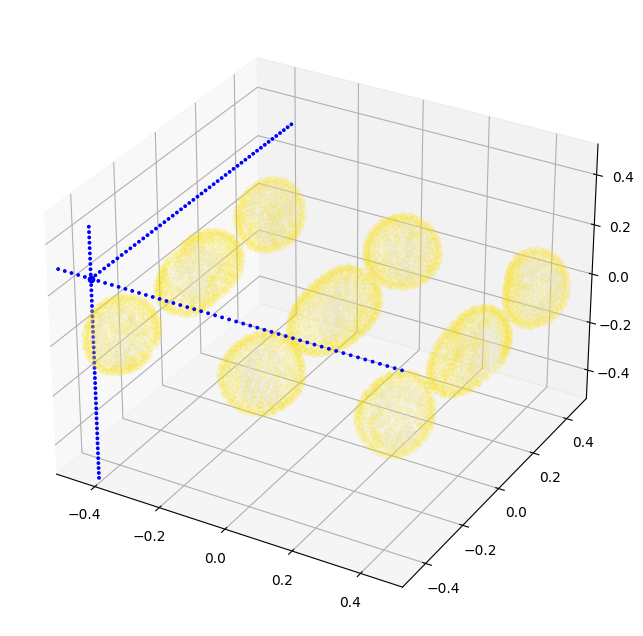

In [226]:

#pc = sampler.output_to_point_clouds(samples)[0]
size = 0.50
fig = plot_point_cloud(pc, grid_size=1, fixed_bounds=((-size, -size, -size),(size, size, size)), grid_1d=True)
# Get the current Axes3D object
ax = plt.gca()
# Reduce the opacity of the point cloud
axes = fig.get_axes()
for ax in axes:
    for coll in ax.collections:
        coll.set_alpha(0.1)  # Set the alpha to 0.5 or any other value less than 1



# Add dotted lines from the point to the respective axes
ax = scatter_spheres(x=-0.4, y=-0.5, z=0.3, ax=ax, col="b", size=size)
#ax = scatter_spheres(x=0.45, y=-0.4, z=0.5, ax=ax, col="b", size=size)
plt.show()

In [293]:
import utils.visibility
import importlib
importlib.reload(utils.visibility)
from utils.visibility import visible_points, covisible_inds

folder = 'images/point_clouds/point_e/'
scale = 0.45
viewpoint = np.array([scale, scale, scale])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pc_torch = torch.tensor(pc.coords, device=device)
viewpoint_torch = torch.tensor(viewpoint, device=device)


kernel = "exponential"
gamma_all = -0.00000000001
gamma = -0.001  # -0.00035
visible_inds, visibility_scores = visible_points(pc_torch, viewpoint=viewpoint_torch, hpr_radius=4,
                                                 compute_weights=True, gamma=gamma, inversion_kernel=kernel)


visibility_scores = visibility_scores.cpu().numpy()
# plot_points(pc.coords, viewpoint, plot_viewpoint=True, out_file=folder + 'fotballs_visible_VS.eps', save=False,
#             points_special_inds=visible_inds)
pc_out = pc.coords[visible_inds]
pc_full = pc.coords
visibility_scores_full = np.zeros(pc.coords.shape[0])
visibility_scores_full[visible_inds] = visibility_scores
#visibility_scores[visibility_scores>-1000] = 0.5
# fig = plot_vs(pc_out, visibility_scores, viewpoint, point_size=1, plot_viewpoint=True, eye_vec=[2,-1,2], cbar=False)
fig = plot_vs(pc_full, visibility_scores_full, viewpoint, point_size=3, plot_viewpoint=True, eye_vec=[2,-1,2], cbar=False)


outfile = 'images/point_clouds/point_e/data_visibility_scores_2_upd2.eps'
if outfile is not None:
    pio.write_image(fig, outfile)
fig.show()

#pio.write_image(fig, out_file)
#plt.show()